In [57]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [58]:
class EmployeeState(TypedDict):
    employee_name: str
    monthly_salary: int
    working_days: int
    completed_projects: int

    yearly_salary: int
    bonus_amount: int
    project_status: str
    summary: str

In [59]:
def calculate_bonus(state: EmployeeState):
    bonus = state['monthly_salary'] * 2
    return {'bonus_amount': bonus}

In [60]:
def calculate_yearly_salary(state: EmployeeState):
    yearly_salary = state['monthly_salary'] * 12
    return {'yearly_salary': yearly_salary}

In [61]:
def project_evaluation(state: EmployeeState):
    if (state['completed_projects'] >= 5):
        status = 'Excellent'
    else:
        status = 'Average'
    return {'project_status': status}

In [62]:
def summary(state: EmployeeState):
    summary_text = f"Employee {state['employee_name']} has a yearly salary of {state['yearly_salary']} and bonus of {state['bonus_amount']}. Project evaluation is {state['project_status']}."
    return {'summary': summary_text}

In [63]:
graph = StateGraph(EmployeeState)

graph.add_node('calculate_bonus', calculate_bonus)
graph.add_node('calculate_yearly_salary', calculate_yearly_salary)
graph.add_node('project_evaluation', project_evaluation)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_bonus')
graph.add_edge(START, 'calculate_yearly_salary')
graph.add_edge(START, 'project_evaluation')
graph.add_edge('calculate_bonus', 'summary')
graph.add_edge('calculate_yearly_salary', 'summary')
graph.add_edge('project_evaluation', 'summary')
graph.add_edge('summary', END)

workflow = graph.compile()

In [64]:
initial_state = {
    'employee_name': 'John Doe',
    'monthly_salary': 5000,
    'working_days': 22,
    'completed_projects': 6
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'employee_name': 'John Doe', 'monthly_salary': 5000, 'working_days': 22, 'completed_projects': 6, 'yearly_salary': 60000, 'bonus_amount': 10000, 'project_status': 'Excellent', 'summary': 'Employee John Doe has a yearly salary of 60000 and bonus of 10000. Project evaluation is Excellent.'}


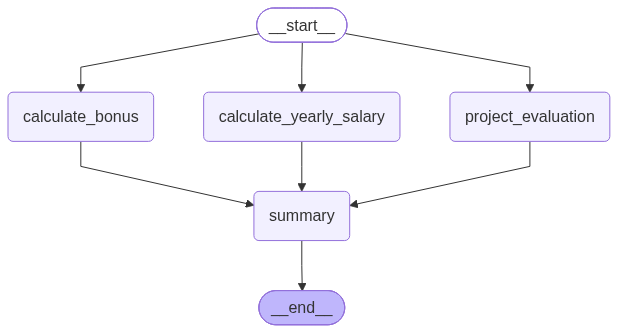

In [65]:
workflow